<a href="https://colab.research.google.com/github/winston-k/Wi20260413/blob/main/py0006h.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Function Estimation

#### We'll try to estimate the quality of red wine samples based on their physical and chemical features
#### We compute and report the mean absolute error, MAE

In [27]:
# CNN version
# Regression Example With wine dataset ...
import pandas as pd
from pandas import read_csv
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


In [28]:
# mounting the Google drive
from google.colab import drive

drive.mount('/content/drive')

# Load the dataset
fp = "/content/drive/My Drive/Emeritus/Wi20260426/Module3-3/wine_r2_t_noheader.csv"




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:

# load dataset to a Pandas dataframe
dataframe = read_csv(fp , header=None)
# copy only values to a numpy n dimensional array, ndarray
dataset = dataframe.values

# split into input (X) and output (Y) variables
X = dataset[:,0:11]
Y = dataset[:,11]

print(X.shape)
X = X.reshape(X.shape[0], X.shape[1], 1)
print(X.shape)


(1599, 11)
(1599, 11, 1)


In [30]:
print(type(dataset))
print(dataset.shape)
print(dataframe.describe())
print( dataframe.head() )

<class 'numpy.ndarray'>
(1599, 12)
                0            1            2            3            4   \
count  1599.000000  1599.000000  1599.000000  1599.000000  1599.000000   
mean      8.319637     0.527821     0.270976     2.538806     0.087467   
std       1.741096     0.179060     0.194801     1.409928     0.047065   
min       4.600000     0.120000     0.000000     0.900000     0.012000   
25%       7.100000     0.390000     0.090000     1.900000     0.070000   
50%       7.900000     0.520000     0.260000     2.200000     0.079000   
75%       9.200000     0.640000     0.420000     2.600000     0.090000   
max      15.900000     1.580000     1.000000    15.500000     0.611000   

                5            6            7            8            9   \
count  1599.000000  1599.000000  1599.000000  1599.000000  1599.000000   
mean     15.874922    46.467792     0.996747     3.311113     0.658149   
std      10.460157    32.895324     0.001887     0.154386     0.169507   
mi

In [31]:
# define base model, a deep covolutional one
# structure comprisses 2 1d convolution layers with 16 and 12 filters, filters are 3x1
# then maxpooling for downsampling, a fully connected dense layer with 12 neurons
# Droput layer with 20% at the end
#

# //Winston20260426 eveApple2100h.ipynb ;
"""

def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv1D(16, 3, activation="relu", input_shape=(11,1)))
    model.add(Conv1D(12, 3, activation="relu"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(12, input_dim=8, kernel_initializer='normal', activation='relu'))
    model.add( Dropout(0.2) )
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

"""



def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv1D(16, 3, activation="relu", input_shape=(11,1)))
    model.add(Conv1D(12, 3, activation="relu"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(12, kernel_initializer='normal', activation='relu')) # Removed input_dim
    model.add( Dropout(0.2) )
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

In [32]:
# splitting the train and test subsets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [33]:
# training the model for 900 epochs and testing the trained model with the training data
# we report the training error

# //Winston20260426 eveApple2100h.ipynb ;

estimator = baseline_model()
estimator.fit(X_train, Y_train, epochs=420, verbose=2)

Epoch 1/420


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 - 4s - 96ms/step - loss: 23.6311
Epoch 2/420
40/40 - 0s - 5ms/step - loss: 10.7480
Epoch 3/420
40/40 - 0s - 7ms/step - loss: 7.6616
Epoch 4/420
40/40 - 0s - 4ms/step - loss: 4.8277
Epoch 5/420
40/40 - 0s - 7ms/step - loss: 3.3605
Epoch 6/420
40/40 - 0s - 8ms/step - loss: 3.2985
Epoch 7/420
40/40 - 0s - 5ms/step - loss: 3.2538
Epoch 8/420
40/40 - 0s - 7ms/step - loss: 2.9620
Epoch 9/420
40/40 - 0s - 4ms/step - loss: 3.0428
Epoch 10/420
40/40 - 0s - 4ms/step - loss: 2.9867
Epoch 11/420
40/40 - 0s - 5ms/step - loss: 2.9383
Epoch 12/420
40/40 - 0s - 5ms/step - loss: 2.7545
Epoch 13/420
40/40 - 0s - 4ms/step - loss: 2.8839
Epoch 14/420
40/40 - 0s - 4ms/step - loss: 3.1140
Epoch 15/420
40/40 - 0s - 8ms/step - loss: 2.8764
Epoch 16/420
40/40 - 0s - 4ms/step - loss: 2.7889
Epoch 17/420
40/40 - 0s - 3ms/step - loss: 2.7667
Epoch 18/420
40/40 - 0s - 3ms/step - loss: 2.8041
Epoch 19/420
40/40 - 0s - 3ms/step - loss: 2.6675
Epoch 20/420
40/40 - 0s - 3ms/step - loss: 2.6843
Epoch 21/420
40/40

In [34]:
# //Winston20260426 eveApple2100h.ipynb ;
# splitted this section off so we don't hv to run all the fit epochs again ;

prediction = estimator.predict(X_train)

train_error =  np.abs(Y_train - prediction)
mean_error = np.mean(train_error)
min_error = np.min(train_error)
max_error = np.max(train_error)
std_error = np.std(train_error)
print('\nTraining results:\nmean=',mean_error,'\nmin=',min_error,'\nmax=',max_error,'\nstd=',std_error)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

Training results:
mean= 0.7284780752146245 
min= 8.440017700195312e-05 
max= 3.876577377319336 
std= 0.5115169455350291


In [35]:
# showing the real and predicted quality scores for the training data
df_train1 = pd.DataFrame({'Actual': Y_train, 'Predicted': prediction.ravel() })
df_train25 = df_train1.tail(25)
print(df_train25)

      Actual  Predicted
1254     6.0   5.496974
1255     6.0   5.444772
1256     5.0   5.318017
1257     5.0   5.574988
1258     6.0   5.254012
1259     5.0   5.448482
1260     5.0   5.596629
1261     5.0   5.541455
1262     6.0   5.677148
1263     6.0   6.155244
1264     5.0   5.327666
1265     5.0   5.766838
1266     5.0   5.331940
1267     4.0   5.254012
1268     5.0   5.436500
1269     6.0   5.889996
1270     6.0   5.798472
1271     6.0   6.521748
1272     6.0   5.778817
1273     5.0   5.337648
1274     5.0   5.290362
1275     5.0   5.322557
1276     6.0   5.395884
1277     6.0   5.801706
1278     5.0   5.254012


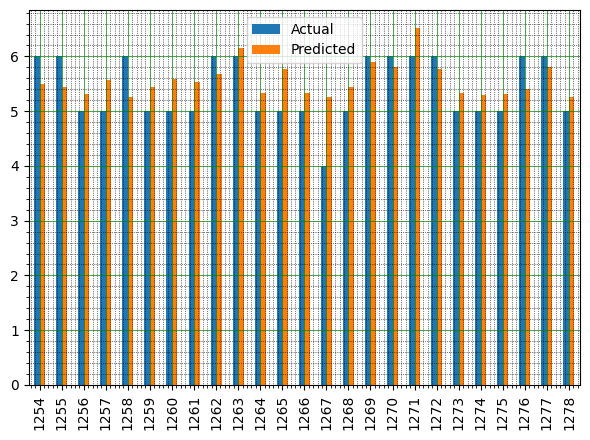

In [36]:
# df1.plot(kind='bar',figsize=(10,8))
# plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
# plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# plt.show()

# //Winston20260426 eveApple2100h.ipynb ;
# cannot see Colab.Gemini code edits in Chrome on Apple ;
df_train25.plot(kind='bar',figsize=(6,4.5))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# //Winston20260426 eveApple2100h.ipynb ;
plt.tight_layout()
plt.show()

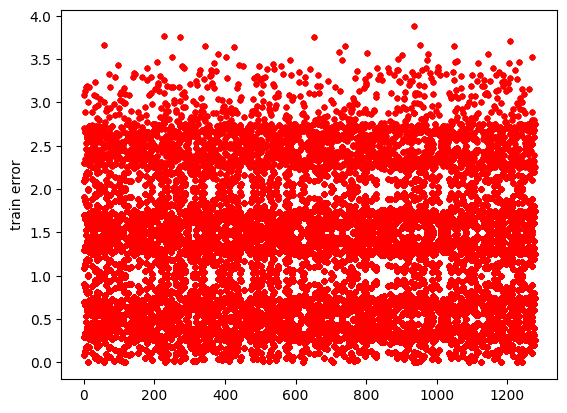

In [37]:
plt.plot(train_error,'r.')
plt.ylabel('train error')
plt.show()

In [38]:
# testing the model with the test data
prediction = estimator.predict(X_test)

test_error =  np.abs(Y_test - prediction)
mean_error = np.mean(test_error)
min_error = np.min(test_error)
max_error = np.max(test_error)
std_error = np.std(test_error)
print('\nTesting results:\nmean=',mean_error,'\nmin=',min_error,'\nmax=',max_error,'\nstd=',std_error)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Testing results:
mean= 0.6800667404197156 
min= 0.0029664039611816406 
max= 3.6607933044433594 
std= 0.4901544324411076


In [39]:
# and showing the results
df_test1 = pd.DataFrame({'Actual': Y_test, 'Predicted': prediction.ravel() })
df_test25 = df_test1.tail(25)
print(df_test25)

     Actual  Predicted
295     6.0   5.742894
296     6.0   5.739947
297     5.0   5.815629
298     6.0   5.327814
299     5.0   5.404369
300     6.0   5.618978
301     5.0   5.254664
302     6.0   5.680069
303     6.0   6.111230
304     6.0   6.118271
305     6.0   5.856244
306     5.0   5.367204
307     5.0   5.286688
308     6.0   5.567279
309     5.0   5.702817
310     5.0   5.608502
311     6.0   6.059756
312     5.0   5.625705
313     5.0   5.790154
314     5.0   5.254012
315     6.0   6.223923
316     4.0   5.820353
317     5.0   6.143499
318     4.0   5.254012
319     6.0   6.044710


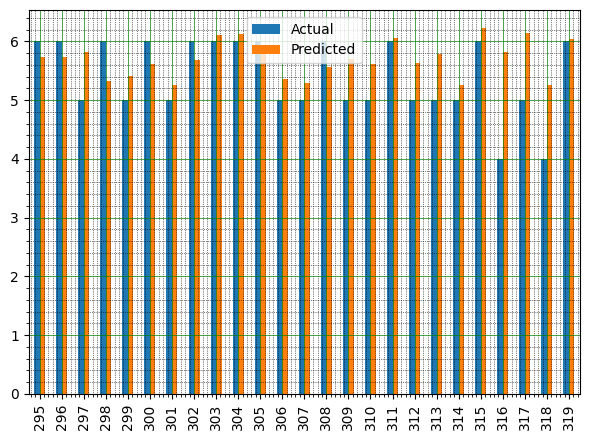

In [40]:
# df1.plot(kind='bar',figsize=(10,8))
# plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
# plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# plt.show()

# //Winston20260426 eveApple2100h.ipynb ;
# cannot see Colab.Gemini code edits in Chrome on Apple ;
df_test25.plot(kind='bar',figsize=(6,4.5))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# //Winston20260426 eveApple2100h.ipynb ;
plt.tight_layout()
plt.show()

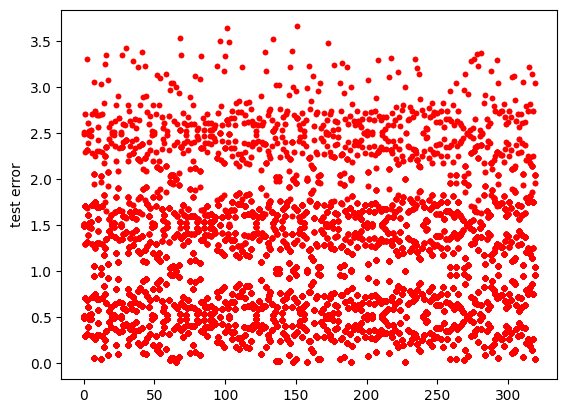

In [41]:
plt.plot(test_error,'r.')
plt.ylabel('test error')
plt.show()

##  Practices
1. train the model for 1400 epochs. what are the training and testing MAE?
2. repeat that with 6000 training epochs. what are the training and testing MAE?
3. move back to 900 training epochs. add two convolutional and one dense layer with the same features of the layers used. what are the training and testing MAE?
4. go for 6000 training epochs. Do you feel any overfitting?
5. set back everything to the original setting, then try to normalize the training and testing features and outputs using standard_scaler. Then see if anything gets better or not. You may use insttructions like what you can see in the next cell.  

#### points:
- use GPU as your runtime type
- if the notebook overflows, change the verbose to 0, e.g. verbose=0 in the training cell.

In [42]:
'''
# normalization
from sklearn.preprocessing import StandardScaler

# Create scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Standardize X_train and X_test
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize Y_train and Y_test (only if y is continuous, e.g., in regression)
y_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1))  # Reshape if needed
y_test_scaled = scaler_y.transform(Y_test.reshape(-1, 1))
'''

'\n# normalization\nfrom sklearn.preprocessing import StandardScaler\n\n# Create scalers\nscaler_X = StandardScaler()\nscaler_y = StandardScaler()\n\n# Standardize X_train and X_test\nX_train_scaled = scaler_X.fit_transform(X_train)\nX_test_scaled = scaler_X.transform(X_test)\n\n# Standardize Y_train and Y_test (only if y is continuous, e.g., in regression)\ny_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1))  # Reshape if needed\ny_test_scaled = scaler_y.transform(Y_test.reshape(-1, 1))\n'